In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import ListedColormap

COLORS = {
    "tumor": "#1f77b4",    
    "immune": "#ff7f0e",    
    "coexist": "green",
    "tumor_dom": "red",
    "tumor_die": "blue"
}

plt.rcParams.update({
    "font.size": 11,
    "figure.figsize": (6,5)
})

In [68]:
import numpy as np
from scipy.optimize import fsolve

def system(vars, rT, rI, a, b, c, d, h):
    T, I = vars
    
    eq1 = rT*T - a*T*T - b*T*I
    eq2 = rI*I - c*I*I + (d*T*I)/(1 + h*T)
    
    return [eq1, eq2]

def jacobian(T, I, rT, rI, a, b, c, d, h):
    
    J11 = rT - 2*a*T - b*I
    J12 = -b*T
    
    J21 = (d*I*(1 + h*T) - d*T*I*h) / ((1 + h*T)**2)
    J22 = rI - 2*c*I + (d*T)/(1 + h*T)
    
    return np.array([[J11, J12],
                     [J21, J22]])

def find_coexistence(rT, rI, a, b, c, d, h):
    

    guesses = [
        [0.5, 0.5],
        [1, 1],
        [2, 1],
        [1, 2],
        [2, 2]
    ]
    
    for guess in guesses:
        sol = fsolve(system, guess, args=(rT, rI, a, b, c, d, h))
        T, I = sol
        
        if T > 1e-6 and I > 1e-6:
            return T, I
    
    return None, None


def analyze_coexistence(rT, rI, a, b, c, d, h):
    
    T_star, I_star = find_coexistence(rT, rI, a, b, c, d, h)
    
    if T_star is None:
        print("No coexistence equilibrium found")
        return
    
    print(f"Coexistence equilibrium: T* = {T_star:.4f}, I* = {I_star:.4f}")
    
    J = jacobian(T_star, I_star, rT, rI, a, b, c, d, h)
    eigvals = np.linalg.eigvals(J)
    
    print("Eigenvalues:", eigvals)
    
    if np.all(np.real(eigvals) < 0):
        print("→ Stable coexistence")
    elif np.any(np.real(eigvals) > 0):
        print("→ Unstable coexistence")
    else:
        print("→ Marginal case")


rT = 1.5
rI = 0.5
a  = 0.4
b  = 0.4
c  = 0.6
d  = 0.3
h  = 1.0

analyze_coexistence(rT, rI, a, b, c, d, h)

Coexistence equilibrium: T* = 2.5572, I* = 1.1928
Eigenvalues: [-0.86927744+0.0729995j -0.86927744-0.0729995j]
→ Stable coexistence


In [19]:
def model(t, y, rT, rI, a, b, c, d, h):
    T, I = y
    
    dTdt = rT*T - a*T*T - b*T*I
    dIdt = rI*I - c*I*I + (d*T*I)/(1 + h*T)
    
    return [dTdt, dIdt]

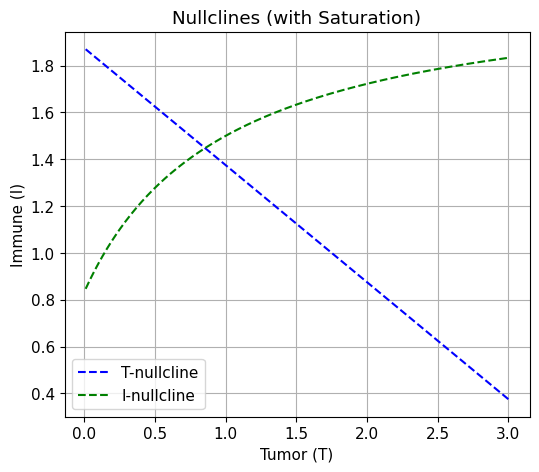

In [69]:

b = 0.8  
d = 0.8

T_vals = np.linspace(0.01, 3, 300)

I_Tnull = (rT - a*T_vals)/b
I_Tnull[I_Tnull < 0] = np.nan

def I_nullcline(T):

    return (rI + (d*T)/(1 + h*T)) / c

I_Inull = I_nullcline(T_vals)

plt.figure()

plt.plot(T_vals, I_Tnull, 'b--', label="T-nullcline")
plt.plot(T_vals, I_Inull, 'g--', label="I-nullcline")

plt.xlabel("Tumor (T)")
plt.ylabel("Immune (I)")
plt.title("Nullclines (with Saturation)")
plt.legend()
plt.grid()

plt.show()

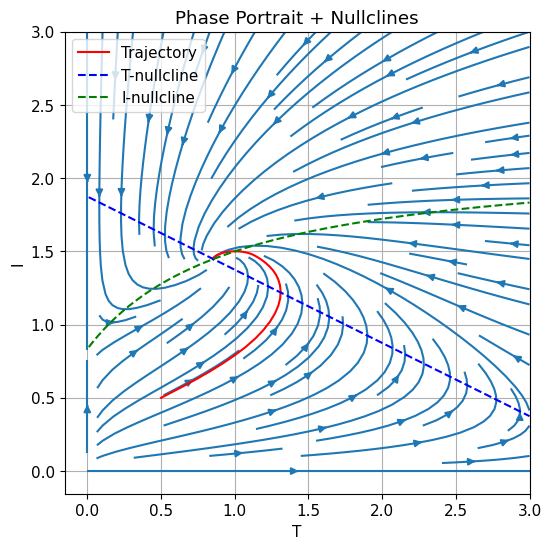

In [70]:
T = np.linspace(0,3,20)
I = np.linspace(0,3,20)
Tg, Ig = np.meshgrid(T, I)

dT = rT*Tg - a*Tg*Tg - b*Tg*Ig
dI = rI*Ig - c*Ig*Ig + (d*Tg*Ig)/(1 + h*Tg)

plt.figure(figsize=(6,6))
plt.streamplot(Tg, Ig, dT, dI, density=1)

sol = solve_ivp(
    model,
    [0,50],
    [0.5,0.5],
    args=(rT, rI, a, b, c, d, h),
    t_eval=np.linspace(0,50,300)
)

plt.plot(sol.y[0], sol.y[1], 'r', label="Trajectory")


plt.plot(T_vals, I_Tnull, 'b--', label="T-nullcline")
plt.plot(T_vals, I_Inull, 'g--', label="I-nullcline")

plt.xlabel("T")
plt.ylabel("I")
plt.title("Phase Portrait + Nullclines")
plt.legend()
plt.grid()

plt.show()

In [ ]:
Bifurcation in b

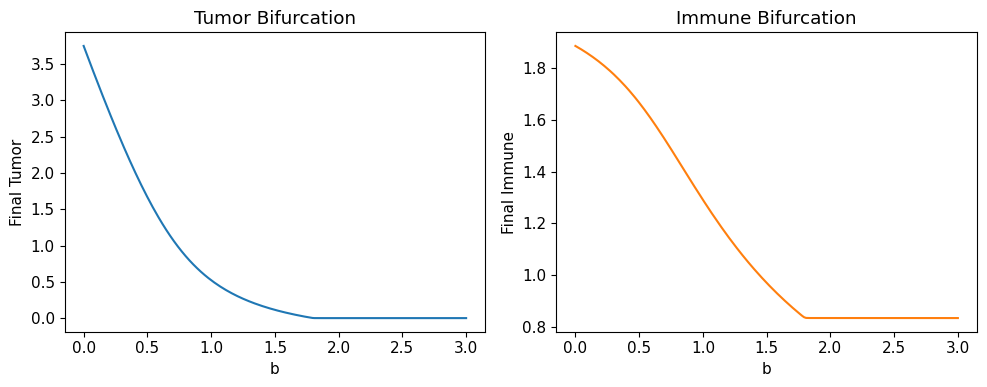

In [22]:
b_values = np.linspace(0, 3, 200)

T_final = []
I_final = []

for b in b_values:
    
    sol = solve_ivp(
        model,
        [0,300],
        [0.5,0.5],
        args=(rT, rI, a, b, c, 0.8, h),  # fix d
        t_eval=np.linspace(0,300,800)
    )
    
    T_series = sol.y[0]
    I_series = sol.y[1]
    
    k = max(5, int(0.1*len(T_series)))
    
    T_final.append(np.mean(T_series[-k:]))
    I_final.append(np.mean(I_series[-k:]))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(b_values, T_final, color=COLORS["tumor"])
plt.xlabel("b")
plt.ylabel("Final Tumor")
plt.title("Tumor Bifurcation")

plt.subplot(1,2,2)
plt.plot(b_values, I_final, color=COLORS["immune"])
plt.xlabel("b")
plt.ylabel("Final Immune")
plt.title("Immune Bifurcation")

plt.tight_layout()
plt.show()

In [71]:
def classify(T_series, I_series):
    k = max(5, int(0.1*len(T_series)))
    Tm = np.mean(T_series[-k:])
    Im = np.mean(I_series[-k:])
    
    if Tm < 1e-2:
        return 0   # tumor dies
    elif Tm > 2*Im:
        return 1   # tumor dominates
    else:
        return 2   # coexistence

In [72]:
rT = 1.8
rI = 0.5
a  = 0.5
c  = 0.5
h  = 0

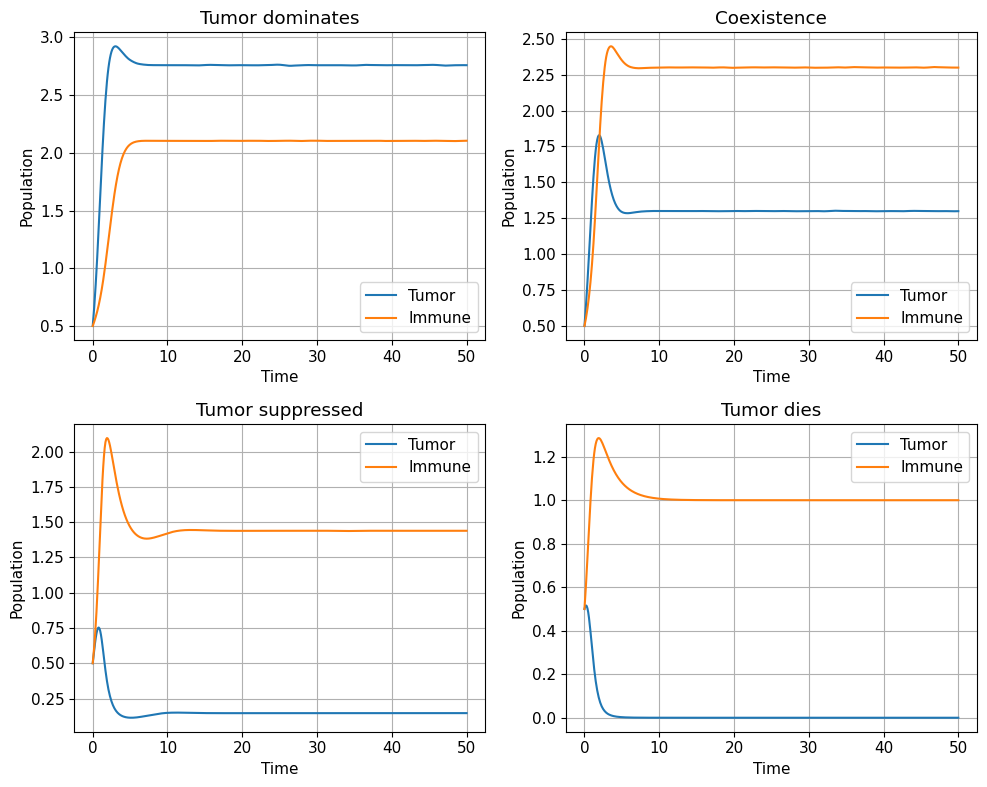

In [73]:
scenarios = [
    ("Tumor dominates", 0.2, 0.2),
    ("Coexistence", 0.5, 0.5),
    ("Tumor suppressed", 1.2, 1.5),
    ("Tumor dies", 2.5, 1.5)
]

fig, axes = plt.subplots(2,2, figsize=(10,8))

for ax, (title, b, d) in zip(axes.flatten(), scenarios):
    
    sol = solve_ivp(
        model,
        [0,50],
        [0.5,0.5],
        args=(rT, rI, a, b, c, d, h),
        t_eval=np.linspace(0,50,500)
    )
    
    ax.plot(sol.t, sol.y[0], color=COLORS["tumor"], label="Tumor")
    ax.plot(sol.t, sol.y[1], color=COLORS["immune"], label="Immune")
    
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Population")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

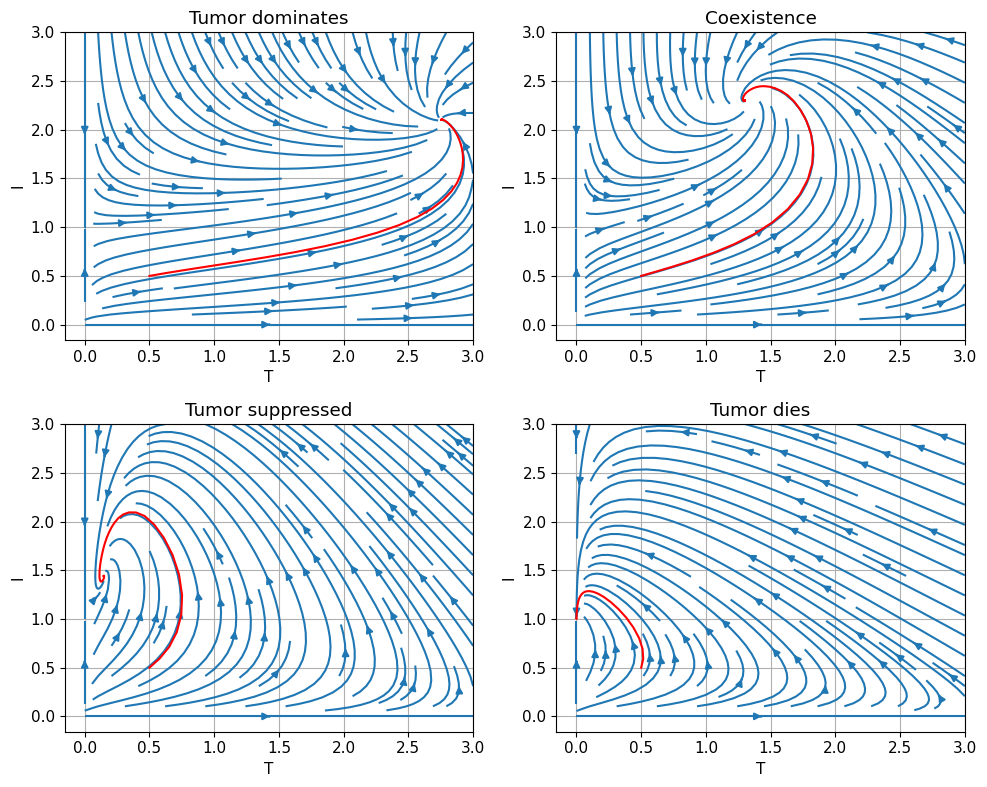

In [63]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

for ax, (title, b, d) in zip(axes.flatten(), scenarios):
    
    T = np.linspace(0,3,20)
    I = np.linspace(0,3,20)
    Tg, Ig = np.meshgrid(T, I)

    dT = rT*Tg - a*Tg*Tg - b*Tg*Ig
    dI = rI*Ig - c*Ig*Ig + (d*Tg*Ig)/(1 + h*Tg)

    ax.streamplot(Tg, Ig, dT, dI, density=1)

    sol = solve_ivp(
        model,
        [0,50],
        [0.5,0.5],
        args=(rT, rI, a, b, c, d, h),
        t_eval=np.linspace(0,50,300)
    )

    ax.plot(sol.y[0], sol.y[1], 'r')
    ax.set_title(title)
    ax.set_xlabel("T")
    ax.set_ylabel("I")
    ax.grid()

plt.tight_layout()
plt.show()

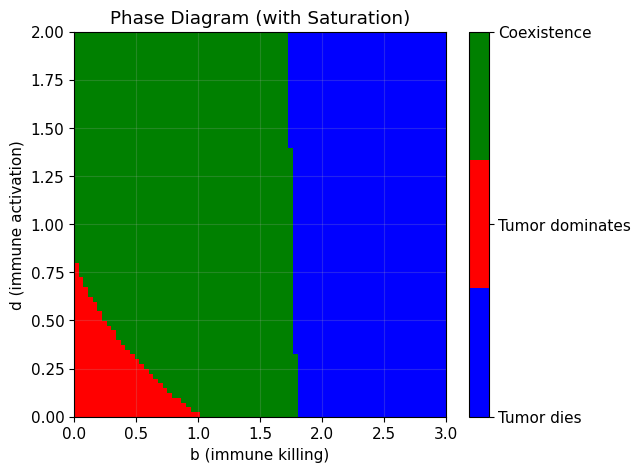

In [7]:
b_values = np.linspace(0, 3, 80)
d_values = np.linspace(0, 2, 80)

result = np.zeros((len(d_values), len(b_values)))

for i, d in enumerate(d_values):
    for j, b in enumerate(b_values):
        
        sol = solve_ivp(
            model,
            [0,300],
            [0.5,0.5],
            args=(rT, rI, a, b, c, d, h),
            t_eval=np.linspace(0,300,800)
        )
        
        result[i,j] = classify(sol.y[0], sol.y[1])

cmap = ListedColormap([
    COLORS["tumor_die"],
    COLORS["tumor_dom"],
    COLORS["coexist"]
])

plt.imshow(
    result,
    extent=[b_values[0], b_values[-1], d_values[0], d_values[-1]],
    origin='lower',
    aspect='auto',
    cmap=cmap
)

cbar = plt.colorbar(ticks=[0,1,2])
cbar.ax.set_yticklabels(["Tumor dies", "Tumor dominates", "Coexistence"])

plt.xlabel("b (immune killing)")
plt.ylabel("d (immune activation)")
plt.title("Phase Diagram (with Saturation)")
plt.grid(alpha=0.2)

plt.show()

In [8]:
import pandas as pd

table_data = []

for b in [0.2, 0.8, 1.5, 2.5]:
    for d in [0.2, 0.8, 1.5]:
        
        sol = solve_ivp(
            model,
            [0,300],
            [0.5,0.5],
            args=(rT, rI, a, b, c, d, h),
            t_eval=np.linspace(0,300,800)
        )
        
        state = classify(sol.y[0], sol.y[1])
        
        if state == 0:
            regime = "Tumor dies"
        elif state == 1:
            regime = "Tumor dominates"
        else:
            regime = "Coexistence"
        
        table_data.append([b, d, regime])

df = pd.DataFrame(table_data, columns=["b", "d", "Regime"])
df

,b,d,Regime
0,0.2,0.2,Tumor dominates
1,0.2,0.8,Coexistence
2,0.2,1.5,Coexistence
3,0.8,0.2,Coexistence
4,0.8,0.8,Coexistence
5,0.8,1.5,Coexistence
6,1.5,0.2,Coexistence
7,1.5,0.8,Coexistence
8,1.5,1.5,Coexistence
9,2.5,0.2,Tumor dies
